In [1]:
import torch
import pandas as pd
from datasets import load_dataset

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


In [2]:
dataset = load_dataset("imdb")
dataset

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [5]:
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print(df_train.shape)
print(df_train.head())

(25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [6]:
def word_count(text):
    return len(text.split())

df_train['word_count'] = df_train['text'].apply(word_count)
df_train.head()

,text,label,word_count
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,288
1,"""I Am Curious: Yellow"" is a risible and preten...",0,214
2,If only to avoid making this type of film in t...,0,93
3,This film was probably inspired by Godard's Ma...,0,118
4,"Oh, brother...after hearing about this ridicul...",0,311


In [8]:
df_train['word_count'].describe()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

In [13]:
df_train['word_count'].quantile(0.95)

np.float64(598.0)

In [14]:
df_train.groupby('label').count()

,text,word_count
label,,
0,12500,12500
1,12500,12500


In [15]:
df_train.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

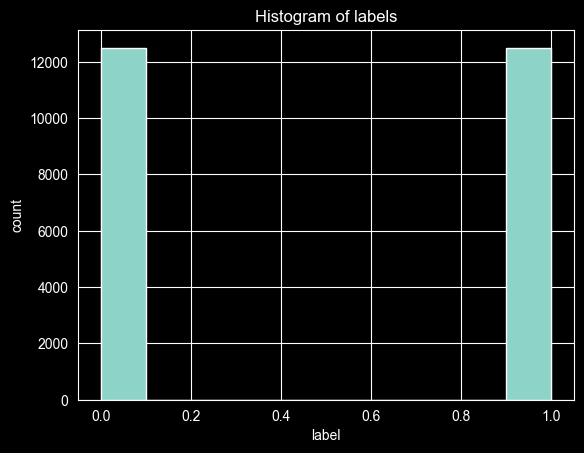

In [18]:
import matplotlib.pyplot as plt
plt.hist(df_train['label'])
plt.xlabel('label')
plt.ylabel('count')
plt.title('Histogram of labels')
plt.show()

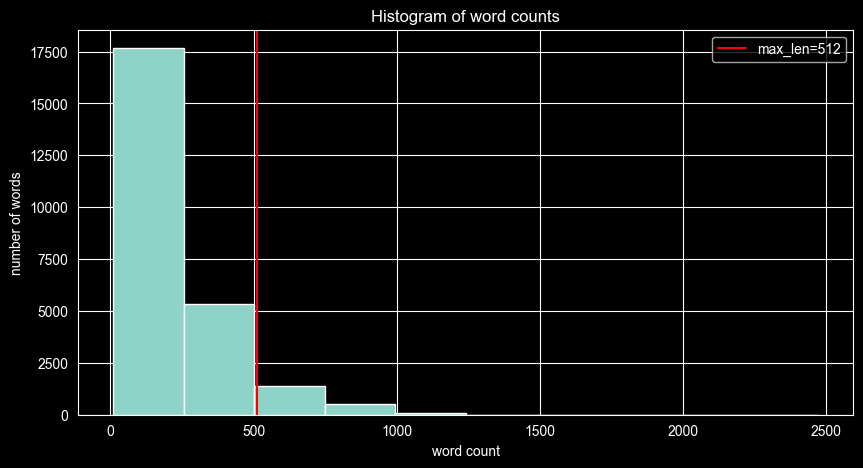

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(df_train['word_count'])
plt.xlabel('word count')
plt.ylabel('number of words')
plt.title('Histogram of word counts')
plt.axvline(512, color='r', label='max_len=512')
plt.legend()
plt.show()

In [29]:
df_train.text[2]

"If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes away with no new perspectives (unless one comes up with one while one's mind wanders, as it will invariably do during this pointless film).<br /><br />One might better spend one's time staring out a window at a tree growing.<br /><br />"

In [33]:
import re
from bs4 import BeautifulSoup


def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)

    return text

df_train['text'] = df_train['text'].apply(clean_text)
df_test['text'] = df_test['text'].apply(clean_text)

In [34]:
df_test

,text,label
0,i love scifi and am willing to put up with a l...,0
1,worth the entertainment value of a rental espe...,0
2,its a totally average film with a few semialri...,0
3,star rating saturday night friday night fri...,0
4,first off let me say if you havent enjoyed a v...,0
...,...,...
24995,just got around to seeing monster man yesterda...,1
24996,i got this as part of a competition prize i wa...,1
24997,i got monster man in a box set of three films ...,1
24998,five minutes in i started to feel how naff thi...,1


In [35]:
df_train.to_parquet("../data/processed/train_clean.parquet")
df_test.to_parquet("../data/processed/test_clean.parquet")